# Boundary Conditions

The discrete operators of the [previous chapter](operators.ipynb) read one
cell beyond each field point. At the edge of the domain that neighbour lies
*outside* the physical region — it is a **ghost cell**, and what we write into
it *is* the boundary condition. This chapter shows how finitevolX frames the
interior with a ghost halo and how the standard boundary types — periodic,
Dirichlet, Neumann, reflective, outflow — are each just a rule for filling
those ghosts {cite}`leveque2002finite,durran2010numerical`.

**What you will learn**

- How ghost cells turn a boundary condition into a local array update
- The five canonical 1-D boundary types and their ghost-fill rules
- How to compose per-face conditions with `BoundaryConditionSet`
- The `enforce_periodic` shortcut somax models use most

## Ghost cells: the boundary as an array update

Recall from the [C-grid chapter](arakawa_cgrid.ipynb) that finitevolX stores
an $n_x\times n_y$ interior inside an $(n_x{+}2)\times(n_y{+}2)$ array. The
outermost ring is the ghost halo. A stencil at the first interior cell, say
the $x$-difference {eq}`ops-diff-x` reused here as

```{math}
:label: bc-stencil
\big(\partial_x h\big)_{j,\,\frac12} \approx \frac{h_{j,1} - h_{j,0}}{\Delta x},
```

reads the ghost value $h_{j,0}$. Choosing $h_{j,0}$ *is* choosing the boundary
condition — no special-cased edge stencils are needed, which keeps the
operators uniform across the whole grid. Each boundary type below is simply a
different formula for the ghost value in terms of the interior.

## The canonical boundary types

{numref}`bc-types-table` lists the ghost-fill rules finitevolX implements as
1-D boundary objects. Let $\phi_{\text{int}}$ be the first interior value
adjacent to the boundary and $\phi_{\text{ghost}}$ the ghost value to fill.

```{list-table} Canonical boundary types and their ghost-fill rules. $\phi_{\text{int}}$ is the adjacent interior value; $h$ is the cell spacing normal to the boundary.
:header-rows: 1
:label: bc-types-table

* - Type
  - finitevolX class
  - Ghost-fill rule
  - Physical meaning
* - Periodic
  - `Periodic1D`
  - $\phi_{\text{ghost}} = \phi_{\text{opposite interior}}$
  - domain wraps (channel, doubly-periodic box)
* - Dirichlet
  - `Dirichlet1D`
  - $\phi_{\text{ghost}} = 2c - \phi_{\text{int}}$
  - fixed boundary value $c$ (e.g. no-slip wall $u=0$)
* - Neumann
  - `Neumann1D`
  - $\phi_{\text{ghost}} = \phi_{\text{int}} + g\,h$
  - fixed normal gradient $g$ (e.g. zero flux)
* - Reflective
  - `Reflective1D`
  - $\phi_{\text{ghost}} = -\phi_{\text{int}}$
  - mirror / free-slip symmetry
* - Outflow
  - `Outflow1D`
  - $\phi_{\text{ghost}} = \phi_{\text{int}}$
  - zero-gradient open boundary
```

The Dirichlet rule is worth a second look: setting the ghost to
$2c-\phi_{\text{int}}$ makes the *average* of the ghost and interior cells
equal $c$, so the interpolated value **at the boundary face** is exactly the
prescribed $c$ — the right way to impose a wall value on a cell-centred field.

In [1]:
import warnings

warnings.filterwarnings("ignore", message=r".*IProgress.*")

import importlib.util
from pathlib import Path

import finitevolx as fvx
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [2]:
try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p numpy,jax,finitevolx,somax")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

watermark extension not installed; skipping reproducibility readout.


## Periodic boundaries: the `enforce_periodic` shortcut

Most somax models run on a doubly-periodic box and call the convenience
`enforce_periodic`, which copies each interior edge into the opposite ghost
ring. We can see it directly: fill the interior with a ramp, then check that
the ghost row mirrors the opposite interior row.

In [3]:
grid = fvx.CartesianGrid2D.from_interior(nx_interior=16, ny_interior=16, Lx=1.0, Ly=1.0)
field = jnp.zeros((grid.Ny, grid.Nx))
ramp = jnp.arange(16 * 16, dtype=float).reshape(16, 16)
field = field.at[1:-1, 1:-1].set(ramp)

field_periodic = fvx.enforce_periodic(field)
# Ghost row 0 should equal the last interior row (-2) after wrapping.
wrapped = bool(jnp.allclose(field_periodic[0, 1:-1], field_periodic[-2, 1:-1]))
print(f"periodic wrap: ghost row 0 == interior row -2 ? {wrapped}")

periodic wrap: ghost row 0 == interior row -2 ? True


## Composing per-face conditions with `BoundaryConditionSet`

Real basins mix conditions: a zonal channel is periodic east–west but walled
north–south. `BoundaryConditionSet` assigns an independent 1-D condition to
each of the four faces and applies them in one call. Here we build the
channel configuration — periodic in $x$, Dirichlet walls in $y$.

In [4]:
channel_bc = fvx.BoundaryConditionSet(
    west=fvx.Periodic1D("west"),
    east=fvx.Periodic1D("east"),
    south=fvx.Dirichlet1D("south", value=0.0),
    north=fvx.Dirichlet1D("north", value=0.0),
)
field_channel = channel_bc(field, dx=grid.dx, dy=grid.dy)

# East-west wrap holds; north-south enforces the wall (face value 0).
ew_periodic = bool(jnp.allclose(field_channel[1:-1, 0], field_channel[1:-1, -2]))
south_face = field_channel[0, 1:-1] + field_channel[1, 1:-1]  # ghost + first interior
print(f"channel: east-west periodic ? {ew_periodic}")
print(
    f"channel: south wall face value ~ 0 ? {bool(jnp.allclose(south_face, 0.0, atol=1e-6))}"
)

channel: east-west periodic ? True
channel: south wall face value ~ 0 ? True


## Visualising the boundary effect

{numref}`bc-comparison-fig` contrasts the two configurations on the same
interior field. Under fully periodic boundaries the ghost ring (outer frame)
carries the wrapped opposite edge; under the channel configuration the
north/south ghosts are the wall reflection while east/west still wrap.

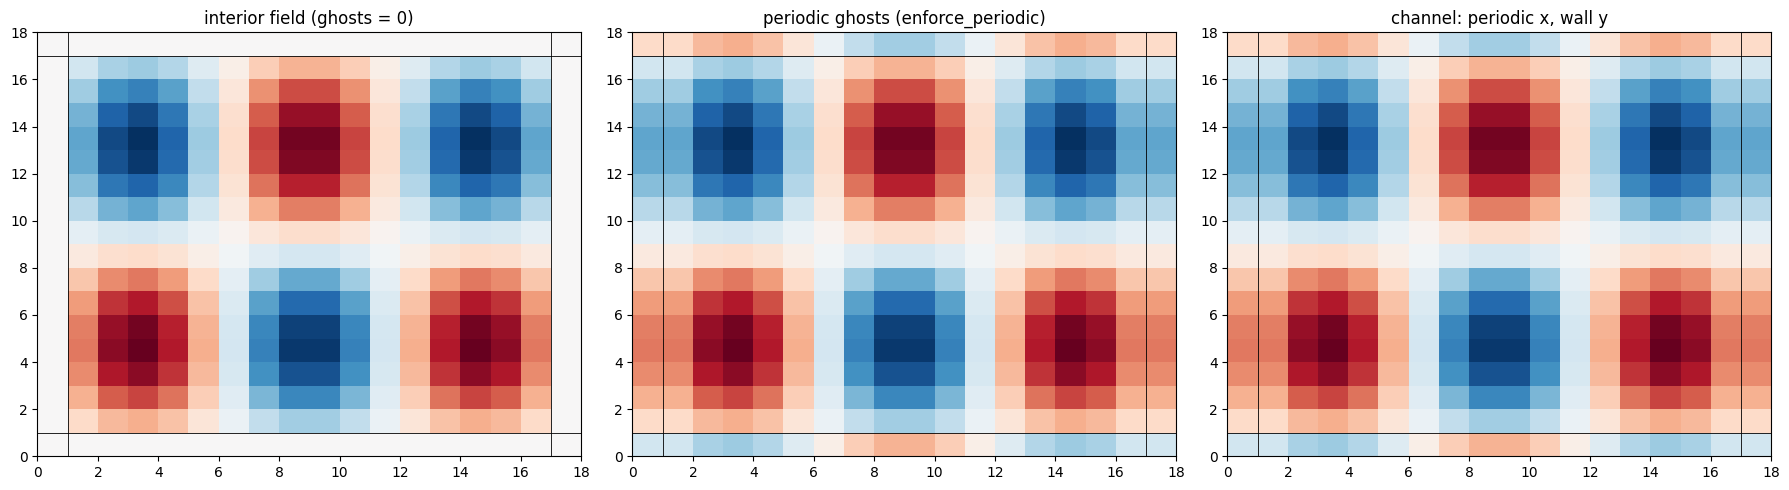

In [5]:
IMG_DIR = Path.cwd().parent / "images" / "boundary_conditions"
IMG_DIR.mkdir(parents=True, exist_ok=True)

# A smoother interior field so the ghost ring is visually legible.
x = jnp.linspace(0.0, 1.0, grid.Nx)
y = jnp.linspace(0.0, 1.0, grid.Ny)
xx, yy = jnp.meshgrid(x, y)
smooth = jnp.zeros((grid.Ny, grid.Nx))
smooth = smooth.at[1:-1, 1:-1].set(
    (jnp.sin(3 * jnp.pi * xx) * jnp.sin(2 * jnp.pi * yy))[1:-1, 1:-1]
)

periodic_full = fvx.enforce_periodic(smooth)
channel_full = channel_bc(smooth, dx=grid.dx, dy=grid.dy)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vlim = float(jnp.max(jnp.abs(smooth)))
kw = dict(cmap="RdBu_r", vmin=-vlim, vmax=vlim)
axes[0].pcolormesh(smooth, **kw)
axes[0].set(title="interior field (ghosts = 0)")
axes[1].pcolormesh(periodic_full, **kw)
axes[1].set(title="periodic ghosts (enforce_periodic)")
axes[2].pcolormesh(channel_full, **kw)
axes[2].set(title="channel: periodic x, wall y")
for ax in axes:
    # mark the interior/ghost boundary
    ax.axhline(1, color="k", lw=0.6)
    ax.axhline(grid.Ny - 1, color="k", lw=0.6)
    ax.axvline(1, color="k", lw=0.6)
    ax.axvline(grid.Nx - 1, color="k", lw=0.6)
fig.tight_layout()
fig.savefig(IMG_DIR / "bc_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

```{figure} ../images/boundary_conditions/bc_comparison.png
:label: bc-comparison-fig
:width: 100%

The same interior field (left, ghosts zeroed) with periodic ghosts filled by
`enforce_periodic` (centre) and with the channel `BoundaryConditionSet`
(right; periodic in $x$, Dirichlet walls in $y$). The thin black frame marks
the interior/ghost boundary.
```

## How somax models use boundary conditions

Each somax model implements `apply_boundary_conditions(state)`, which the time
integrator calls before every right-hand-side evaluation so the operators
always read boundary-consistent ghosts. A doubly-periodic model maps
`enforce_periodic` over each state field; a walled model applies the
appropriate wall (Dirichlet / reflective) condition per field and face. The
boundary type is therefore part of the model's physical specification, not an
afterthought — it is enforced at every step, never skipped.

## Summary

- A boundary condition is a rule for filling the **ghost cells** the stencils read ({eq}`bc-stencil`); no special edge stencils are required.
- The five canonical types — periodic, Dirichlet, Neumann, reflective, outflow — are distinct ghost-fill formulas ({numref}`bc-types-table`).
- `enforce_periodic` handles the common doubly-periodic case; `BoundaryConditionSet` composes independent per-face conditions ({numref}`bc-comparison-fig`).
- somax models enforce their boundary conditions inside `apply_boundary_conditions`, called before every RHS evaluation.

This completes the Phase 0 foundations — grids, operators, and boundary conditions. The model chapters build on these primitives to assemble the shallow-water and quasi-geostrophic dynamics.

## References

```{bibliography}
:filter: docname in docnames
```